In [3]:
pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached grpcio-1.76.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)
Using cached grpcio-1.76.0-cp313-cp313-win_amd64.whl (4.7 MB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
Using cached absl_py-2.3.1-py

In [5]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
dataset=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
## divide independent and  dependent variables

In [11]:
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

In [13]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [14]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [ ]:
## Feature engineering

In [15]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns
print(cat_cols)


Index(['Geography', 'Gender'], dtype='object')


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object'):
    X[col] = le.fit_transform(X[col])

In [18]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [19]:
#Splitting dataset into Train Test Split

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
#feature scaling

In [25]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)


In [26]:
X_train

array([[ 1.058568  , -0.90593285,  0.90750738, ...,  0.64104192,
        -1.030206  ,  1.04208392],
       [ 0.91362605,  0.30016846,  0.90750738, ...,  0.64104192,
        -1.030206  , -0.62355635],
       [ 1.07927399,  0.30016846, -1.10191942, ...,  0.64104192,
         0.97067965,  0.30812779],
       ...,
       [ 0.16821031, -0.90593285, -1.10191942, ...,  0.64104192,
         0.97067965, -0.55808767],
       [ 0.37527024,  1.50626978,  0.90750738, ...,  0.64104192,
        -1.030206  , -1.35149956],
       [ 1.56586482,  1.50626978,  0.90750738, ..., -1.55996038,
         0.97067965, -1.02692216]])

In [27]:
X_test

array([[-0.66718803, -0.88588013,  0.93228691, ...,  0.66636576,
        -1.03252879, -0.1245155 ],
       [-1.28654133,  0.332662  ,  0.93228691, ..., -1.50067735,
        -1.03252879, -0.79840989],
       [-0.95621957,  1.55120414, -1.07263117, ..., -1.50067735,
         0.968496  ,  0.06712409],
       ...,
       [-1.37944433,  0.332662  , -1.07263117, ..., -1.50067735,
        -1.03252879,  0.82644477],
       [ 0.4063577 , -0.88588013,  0.93228691, ..., -1.50067735,
        -1.03252879, -1.48855742],
       [ 1.03603357, -0.88588013,  0.93228691, ...,  0.66636576,
        -1.03252879, -0.51894491]])

In [29]:
X_train.shape

(8000, 10)

In [31]:
X_test.shape

(2000, 10)

In [32]:
# ANN

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [34]:
# lets initialise ANN
classifier=Sequential()

In [35]:
#Adding input layer

In [36]:
classifier.add(Dense(units=11,activation='relu'))

In [37]:
#adding first hidden layer

In [38]:
classifier.add(Dense(units=7,activation='relu'))

In [39]:
#adding second hidden layer

In [40]:
classifier.add(Dense(units=6,activation='relu'))

In [41]:
#adding second output layer

In [42]:
classifier.add(Dense(1,activation='sigmoid'))

In [46]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [47]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [51]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8718 - loss: 0.3164 - val_accuracy: 0.8561 - val_loss: 0.3602
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8709 - loss: 0.3205 - val_accuracy: 0.8561 - val_loss: 0.3633
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8698 - loss: 0.3177 - val_accuracy: 0.8557 - val_loss: 0.3819
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8714 - loss: 0.3186 - val_accuracy: 0.8519 - val_loss: 0.3760
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8690 - loss: 0.3194 - val_accuracy: 0.8542 - val_loss: 0.3703
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8701 - loss: 0.3194 - val_accuracy: 0.8550 - val_loss: 0.3629
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8688 - loss: 0.3183 - val_accuracy: 0.8546 - val_loss: 0.3808
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8733 - loss: 0.3151 - 

KeyboardInterrupt: 

In [52]:
#Early Stopping

In [53]:
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [54]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8679 - loss: 0.3170 - val_accuracy: 0.8527 - val_loss: 0.3981
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8679 - loss: 0.3176 - val_accuracy: 0.8512 - val_loss: 0.3799
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8709 - loss: 0.3158 - val_accuracy: 0.8508 - val_loss: 0.4032
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8716 - loss: 0.3173 - val_accuracy: 0.8538 - val_loss: 0.3692
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8690 - loss: 0.3157 - val_accuracy: 0.8546 - val_loss: 0.3733
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8699 - loss: 0.3150 - val_accuracy: 0.8535 - val_loss: 0.3912
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8698 - loss: 0.3184 - val_accuracy: 0.8554 - val_loss: 0.3754
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8709 - loss: 0.3129 - 

In [55]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [56]:
#summarize the history for accuracy

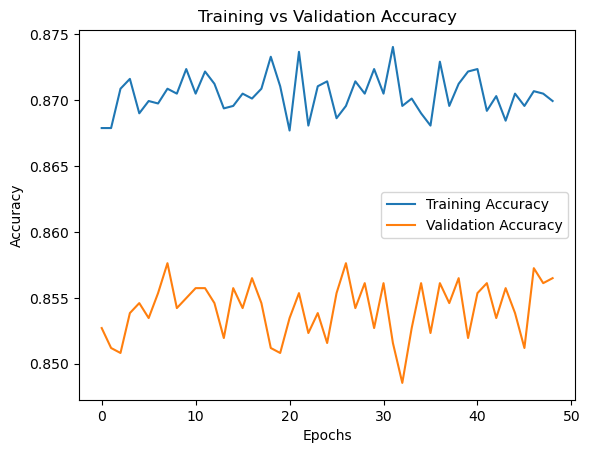

In [57]:
plt.figure()
plt.plot(model_history.history['accuracy'], label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


In [58]:
#prediction and evaluation of the model

In [59]:
#predict test data result

In [61]:
y_pred=classifier.predict(X_test)
y_pred=(y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step


In [63]:
# make the confusion matrics
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm


array([[1533,   60],
       [ 243,  164]])

In [64]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [65]:
score

0.8485

In [66]:
#get the weights

In [68]:
classifier.get_weights()

[array([[-1.8482150e+00, -3.0951407e+00, -7.4309659e-01, -1.1830858e+00,
         -1.8144038e+00, -1.7050649e+00,  1.6878765e+00, -2.6959702e-02,
         -5.6768603e+00, -1.0994354e+00,  4.4888210e-01],
        [ 4.4789270e-01, -3.9814508e+00,  3.3882159e-01,  9.7957540e-01,
          4.9866004e+00,  2.3445704e+00, -2.4986765e+00, -1.2275940e+00,
          2.9950950e+00, -7.9031372e+00, -1.4386588e+00],
        [-1.0089658e+00,  1.0794204e+00,  2.8718632e-01, -3.1368108e-05,
          1.9704041e+00,  1.7631757e+00, -4.3051624e+00,  2.2220309e+00,
         -1.4614515e+00,  6.8658292e-01, -7.0784146e-01],
        [ 1.0665423e+00,  5.3668624e-01,  6.1829734e+00,  2.1587207e+00,
         -4.2448988e+00,  1.0482008e+00, -9.7588072e+00, -7.4819803e+00,
         -5.2042346e+00, -4.9664969e+00, -2.0532928e+00],
        [ 2.7120197e+00,  7.5179243e-01,  5.0919461e-01, -5.1258463e-02,
          3.4334347e-01,  5.6834096e-01,  1.8712619e-01,  8.1540990e-01,
         -2.8025088e+00,  2.3725404e-0